In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Data Loading and Cleaning

In [2]:
# Load data
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Handle Missing Values
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Standardize Categories
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# Feature Engineering: Split Blood Pressure
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Person ID', 'Blood Pressure'])

print("Data Cleaned. Shape:", df.shape)

Data Cleaned. Shape: (374, 13)


In [3]:
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95



# 2. Exploratory Data Analysis (Visualization)

C:\Users\jangr\AppData\Local\Temp\ipykernel_18848\2316516257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sleep Disorder', palette='pastel')


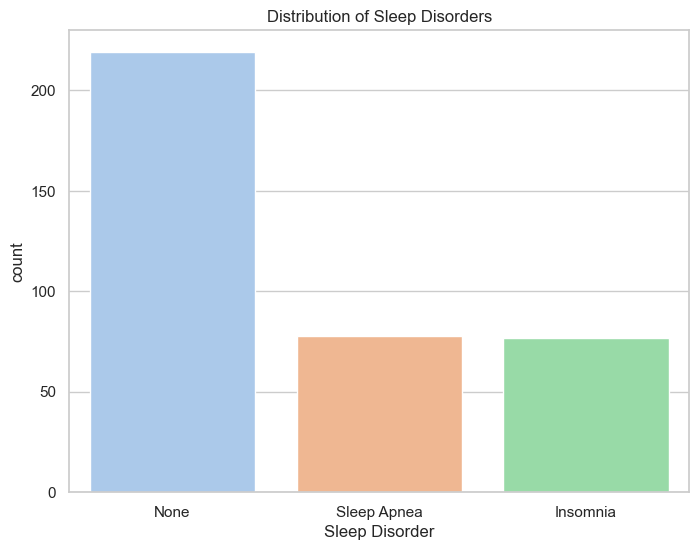

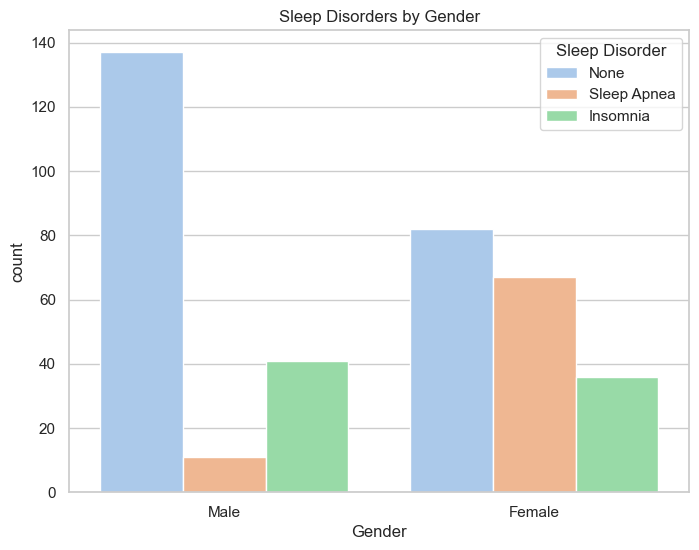

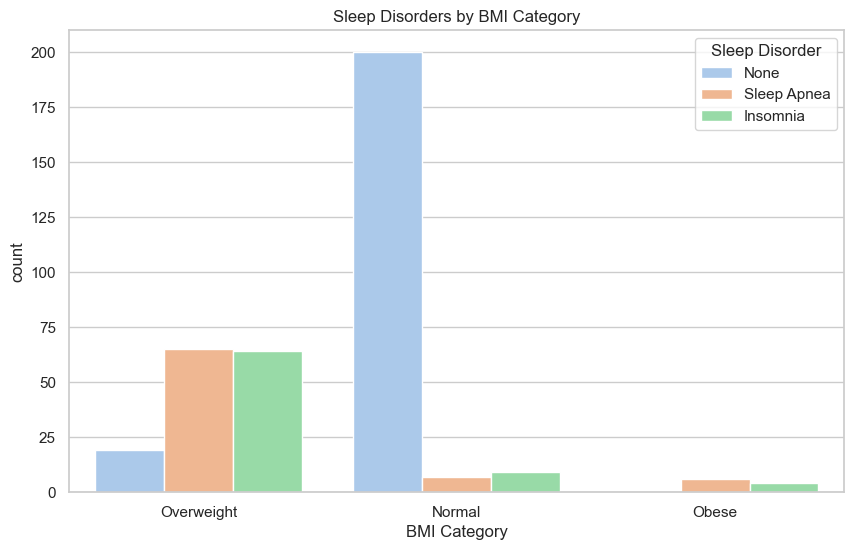

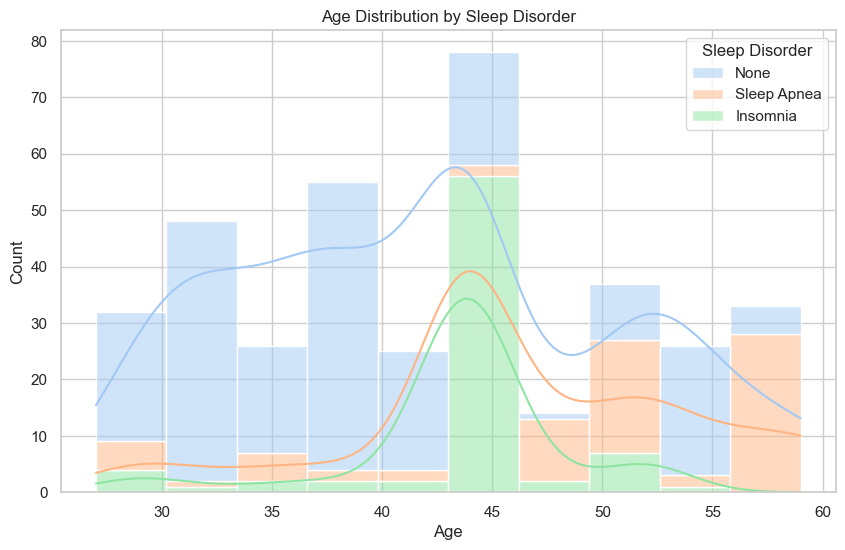

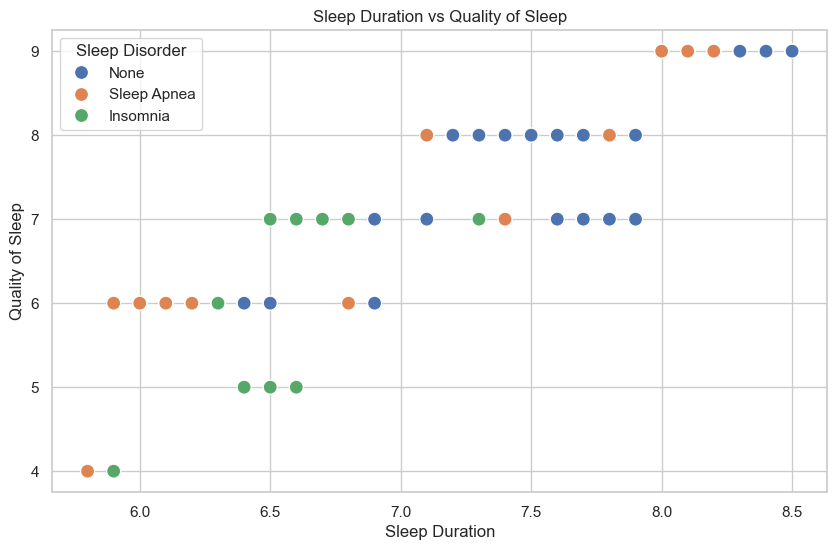

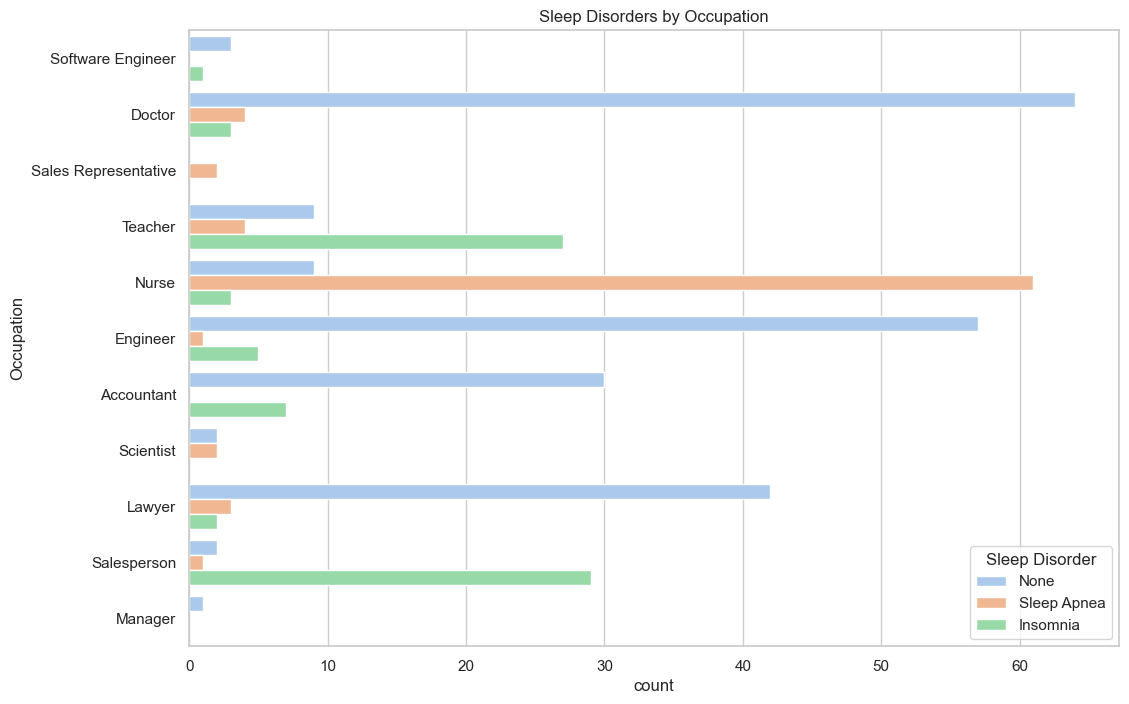

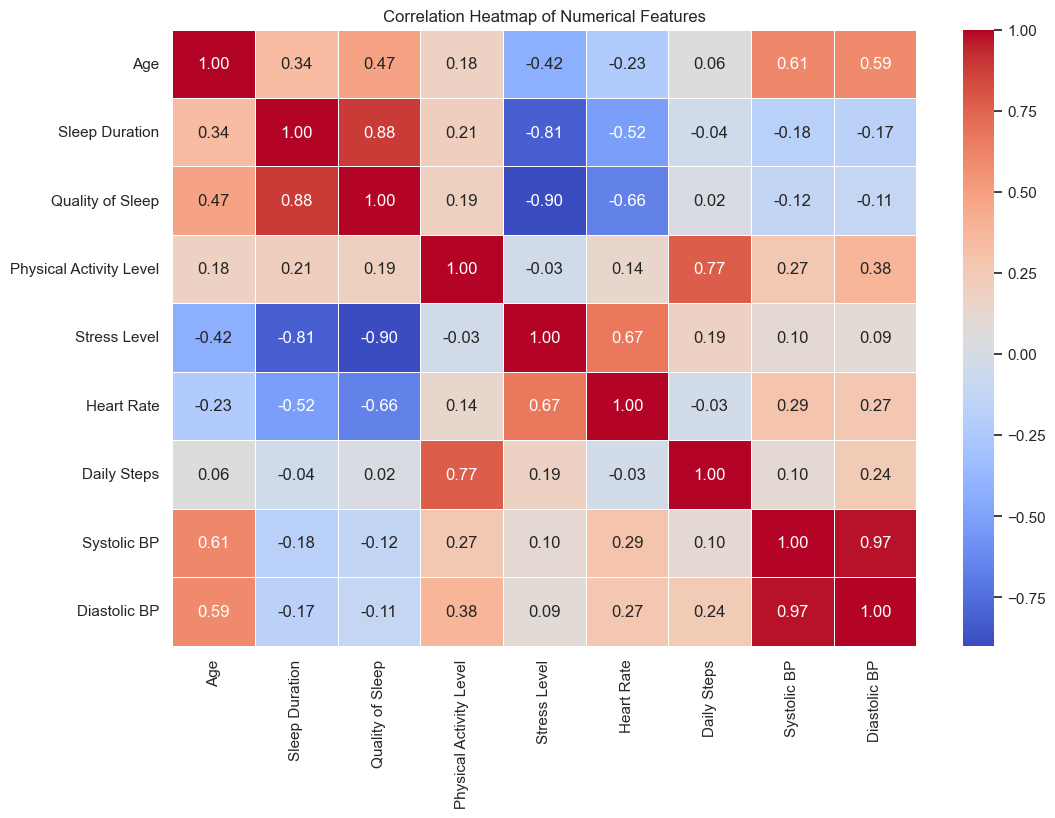

In [4]:
sns.set(style="whitegrid")

#  Plot 1: Overall Distribution of Sleep Disorders 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sleep Disorder', palette='pastel')
plt.title('Distribution of Sleep Disorders')
plt.show()

# Plot 2: Sleep Disorders by Gender
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', hue='Sleep Disorder', palette='pastel')
plt.title('Sleep Disorders by Gender')
plt.show()

# Plot 3: Sleep Disorders by BMI Category 
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='BMI Category', hue='Sleep Disorder', palette='pastel')
plt.title('Sleep Disorders by BMI Category')
plt.show()

# Plot 4: Age Distribution by Sleep Disorder 
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Sleep Disorder', kde=True, multiple="stack", palette='pastel')
plt.title('Age Distribution by Sleep Disorder')
plt.show()

# Plot 5: Sleep Duration vs Quality of Sleep 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sleep Duration', y='Quality of Sleep', hue='Sleep Disorder', palette='deep', s=100)
plt.title('Sleep Duration vs Quality of Sleep')
plt.show()

# Plot 6: Sleep Disorders by Occupation 
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Occupation', hue='Sleep Disorder', palette='pastel')
plt.title('Sleep Disorders by Occupation')
plt.show()

# Plot 7: Correlation Heatmap
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
# Plot heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 3. Model Training and Evaluation

In [5]:
# Prepare Features (X) and Target (y)
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

In [6]:
# Encode Target (None=0, Insomnia=1, Apnea=2 roughly, depends on auto-encoding)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Target Classes: {list(enumerate(class_names))}")

Target Classes: [(0, 'Insomnia'), (1, 'None'), (2, 'Sleep Apnea')]


In [7]:
# Preprocessing Pipeline
categorical_cols = ['Gender', 'Occupation', 'BMI Category']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [9]:
# Define Models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42)
}

In [10]:
# Training Loop
results = []
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name, 
        'Accuracy': acc, 
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1': report['weighted avg']['f1-score']
    })

c:\Users\jangr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
# Display Results
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\nModel Comparison Table:")
print(results_df)


Model Comparison Table:
                 Model  Accuracy  Precision    Recall        F1
2  Logistic Regression  0.960000   0.966316  0.960000  0.960685
1        Random Forest  0.946667   0.948235  0.946667  0.947196
0        Decision Tree  0.920000   0.927111  0.920000  0.921645


# 4. Feature Importance 

In [12]:

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
# Extract feature names and importances
rf_model = rf_pipeline.named_steps['classifier']
preprocessor_step = rf_pipeline.named_steps['preprocessor']
ohe_feature_names = preprocessor_step.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([ohe_feature_names, numeric_cols])

In [14]:

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

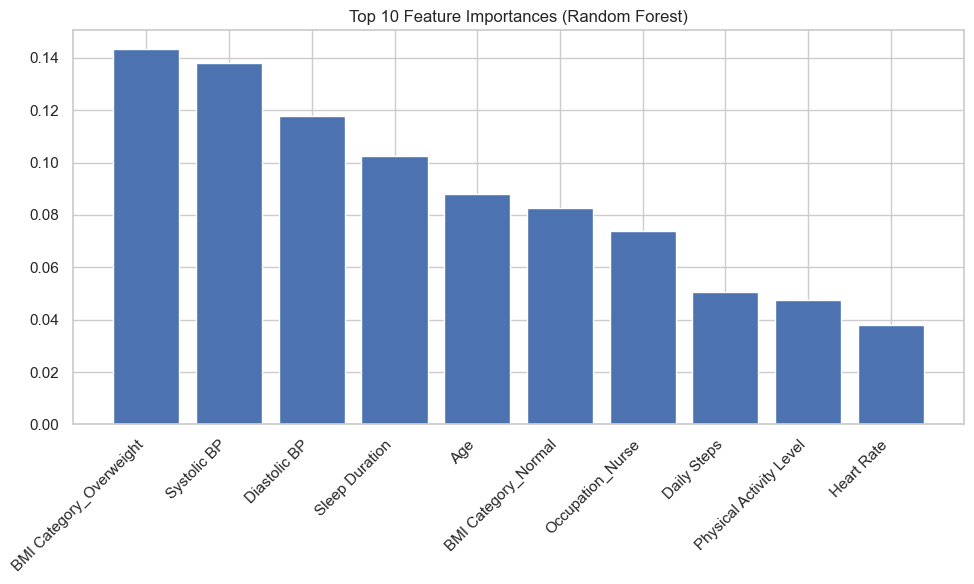

In [15]:
# Plot Top 10 Features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), all_feature_names[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()